In [1]:
#!/usr/bin/env python3
"""
==============================================================================
HAOR FLOOD — MULTI-YEAR ANALYSIS v2  (haor_flood_multiyear.ipynb)
==============================================================================
Everything from v1 PLUS the next-step analyses:

  NEW in v2:
  A. Sharper merge metrics — merge fraction computed within the WET SEASON only
     (between earliest onset and latest recession), plus first/last full-merge
     date and merged-duration per year. Fixes the diluted-looking bars of v1.
  B. Side-by-side multi-year grids of the single-year figures: hydrographs,
     connectivity, onset boxplots, offset boxplots — one panel per year.
  C. Kendall's W — a formal test that the drain order (GMA first ... MTN last)
     is non-random across the 7 years.
  D. BARRIER / ELEVATION MECHANISM — extracts FABDEM elevation along each
     haor's rim ("outlet proxy" = lowest rim percentile) and along each
     adjacent-pair boundary corridor ("sill"), then rank-correlates rim
     elevation with the 7-year drain order. Tests WHY GMA drains first.
  E. SWOT VALIDATION — indexes your SWOT_L2_HR_Raster NetCDFs, extracts
     per-haor median water-surface elevation (WSE) with QC filters, matches
     SWOT dates to the connectivity matrix (2023+), and compares |ΔWSE|
     between haor pairs labelled MERGED vs SEPARATE by the radar analysis.
     If merged pairs share one elevation and separate pairs do not, the
     contiguity method measures real hydraulic connection.

RUN ORDER: cells top to bottom. Per-year analysis first (it feeds everything),
then cross-year, then mechanism, then SWOT.
==============================================================================
"""
import os, re, glob, datetime
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import geometry_mask
from rasterio.mask import mask as rmask
from rasterio.warp import reproject, Resampling
from shapely.geometry import mapping
from scipy import ndimage
from scipy.stats import spearmanr
print("\u2713 imports ok")


✓ imports ok


In [2]:
# %%
# ============================ PATHS & CONFIG ============================
BASE      = "/work/a06/wasif/haor_flood_analysis_multiyear"
HAORS_SHP = "/work/a06/wasif/haor_flood_analysis/digitization/haors_manual.shp"
FABDEM_TIF = "/work/a06/wasif/haor_flood_analysis/fabdem_elevation.tif"   # 30 m, broad region
JRC_CANDIDATES = [
    "/work/a06/wasif/haor_flood_analysis/haor_digitization_tanguar/tanguar_jrc_occurrence.tif",
    "/work/a06/wasif/haor_flood_analysis/jrc_water_occurrence.tif",
    os.path.join(BASE, "tanguar_jrc_occurrence.tif"),
]
JRC_TIF = next((p for p in JRC_CANDIDATES if os.path.exists(p)), None)
assert JRC_TIF, "No JRC occurrence raster found - check JRC_CANDIDATES paths."

# SWOT
SWOT_DIR = "/work/a06/wasif/swot_raster_data"
SWOT_INDEX_CSV = os.path.join(BASE, "analysis", "swot_file_index.csv")
CLUSTER_BBOX = [90.85, 24.85, 91.50, 25.25]   # W,S,E,N

ANALYSIS_ROOT = os.path.join(BASE, "analysis")
os.makedirs(ANALYSIS_ROOT, exist_ok=True)

# analysis knobs (identical to the validated single-year settings)
PERMANENT_WATER_THRESHOLD = 75
LEVEL = 0.50
MIN_PX, BRIDGE = 10, 1
MIN_OBSERVED_FRAC = 0.50
BUFFER_PX = 8
CENTRAL_HAOR = "GMA"

YEARS = sorted(int(re.search(r"(\d{4})", os.path.basename(f)).group(1))
               for f in glob.glob(os.path.join(BASE, "flood_stack_cluster_*.tif")))
print("JRC:", JRC_TIF)
print("years found:", YEARS)

os.environ["SHAPE_RESTORE_SHX"] = "YES"
haors = gpd.read_file(HAORS_SHP)
haors = haors[haors["haor_id"] != "DUMMY"].copy()
HAOR_IDS = haors["haor_id"].tolist()
print("haors:", HAOR_IDS)


JRC: /work/a06/wasif/haor_flood_analysis/haor_digitization_tanguar/tanguar_jrc_occurrence.tif
years found: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
haors: ['MTN', 'SHN', 'HLR', 'TGR', 'GMA']


In [3]:
# %%
# ============================ REUSED HELPERS ============================
def extract_onset_masked(haor_geom, fwd_src, jrc_src):
    """Per-pixel day values inside a haor, permanent water removed (verbatim
    from 5_haor_flood_onset2). Works for first_wet AND last_wet rasters."""
    geom_fwd = gpd.GeoSeries([haor_geom], crs=haors.crs).to_crs(fwd_src.crs).iloc[0]
    fwd_data, fwd_transform = rmask(fwd_src, [mapping(geom_fwd)], crop=True, filled=False)
    fwd_arr = fwd_data[0]
    fwd_mask = np.ma.getmaskarray(fwd_arr) if np.ma.isMaskedArray(fwd_arr) else np.zeros(fwd_arr.shape, bool)
    fwd_vals = np.ma.filled(fwd_arr, np.nan).astype("float32")
    out_h, out_w = fwd_vals.shape
    jrc_on_grid = np.full((out_h, out_w), np.nan, dtype="float32")
    reproject(source=rasterio.band(jrc_src, 1), destination=jrc_on_grid,
              src_transform=jrc_src.transform, src_crs=jrc_src.crs,
              dst_transform=fwd_transform, dst_crs=fwd_src.crs,
              resampling=Resampling.bilinear)
    valid = (~fwd_mask) & np.isfinite(fwd_vals) & (fwd_vals > 0)
    not_perm = ~(np.isfinite(jrc_on_grid) & (jrc_on_grid > PERMANENT_WATER_THRESHOLD))
    keep = valid & not_perm
    return fwd_vals[keep], int(np.sum(valid & ~not_perm))

def _doy(desc):
    m = re.search(r"(20\d{2})(\d{2})(\d{2})", desc or "")
    if not m: return np.nan
    y, mo, d = map(int, m.groups())
    return datetime.date(y, mo, d).timetuple().tm_yday
print("\u2713 helpers defined")


✓ helpers defined


In [4]:
# %%
# ====================== PER-YEAR ANALYSIS FUNCTION (v2) ======================
# Same pipeline as v1 (hydrographs -> timing -> connectivity -> per-pixel
# onset/offset) with two v2 additions:
#   - returns curves/days/onset_dist/offset_dist so the multi-year grid figures
#     can be drawn without re-reading rasters
#   - wet-season merge metrics in the summary (merge fraction WITHIN the wet
#     season, first/last full-merge day, number of merged dates)
def analyze_year(year, make_figs=False):
    stack_tif = os.path.join(BASE, f"flood_stack_cluster_{year}.tif")
    fwd_tif   = os.path.join(BASE, f"first_wet_date_{year}.tif")
    lwd_tif   = os.path.join(BASE, f"last_wet_date_{year}.tif")
    for p in (stack_tif, fwd_tif, lwd_tif):
        if not os.path.exists(p):
            print(f"  [{year}] missing {os.path.basename(p)} - skipping"); return None
    outdir = os.path.join(ANALYSIS_ROOT, str(year)); os.makedirs(outdir, exist_ok=True)

    with rasterio.open(stack_tif) as src:
        nod = src.nodata
        hv = haors.to_crs(src.crs)
        days = np.array([_doy(d) for d in src.descriptions], float)
        bands = []
        for i in range(src.count):
            b = src.read(i + 1).astype("float32")
            if nod is not None: b[b == nod] = np.nan
            bands.append(b)
        shape, transform = (src.height, src.width), src.transform
        masks = {h.haor_id: geometry_mask([h.geometry], shape, transform, invert=True)
                 for _, h in hv.iterrows()}

    curves = {}
    for hid, m in masks.items():
        fr = []
        for b in bands:
            sub = b[m]; obs = np.isfinite(sub); nobs = int(obs.sum())
            fr.append(int((sub[obs] == 1).sum()) / nobs if nobs else np.nan)
        curves[hid] = np.array(fr, float)
    pd.DataFrame({"doy": days, **curves}).sort_values("doy").to_csv(
        os.path.join(outdir, f"haor_hydrograph_curves_{year}.csv"), index=False)

    trows = []
    for hid in curves:
        f = curves[hid]; ok = np.isfinite(f)
        d, ff = days[ok], f[ok]; o = np.argsort(d); d, ff = d[o], ff[o]
        if ff.size == 0 or not np.isfinite(np.nanmax(ff)): continue
        fmax = np.nanmax(ff); above = d[ff >= LEVEL * fmax]
        trows.append(dict(haor_id=hid,
            onset_hydro=float(above.min()) if above.size else np.nan,
            peak_hydro=float(d[np.argmax(ff)]),
            recession_hydro=float(above.max()) if above.size else np.nan,
            max_fraction=round(float(fmax), 3)))
    timing = pd.DataFrame(trows)
    timing.to_csv(os.path.join(outdir, f"haor_hydrograph_timing_{year}.csv"), index=False)

    cluster_pixels = np.zeros(shape, bool)
    for m in masks.values(): cluster_pixels |= m
    study = ndimage.binary_dilation(cluster_pixels, iterations=BUFFER_PX)
    n_cluster = int(cluster_pixels.sum())
    crecs, cmat = [], []
    for i, b in enumerate(bands):
        observed = np.isfinite(b)
        obs_frac = (observed & cluster_pixels).sum() / n_cluster if n_cluster else 0.0
        if obs_frac < MIN_OBSERVED_FRAC:
            crecs.append(dict(doy=days[i], n_components=-1, largest_frac=-1, total_wet=-1,
                              obs_frac=round(obs_frac, 3), all_connected=False))
            cmat.append(dict(doy=days[i], **{h: -1 for h in masks})); continue
        water = observed & (b == 1) & study
        if BRIDGE: water = ndimage.binary_opening(water, iterations=BRIDGE)
        lab, n = ndimage.label(water)
        if n:
            sz = ndimage.sum(np.ones_like(lab), lab, index=np.arange(1, n + 1))
            water &= np.isin(lab, np.where(sz >= MIN_PX)[0] + 1)
            lab, n = ndimage.label(water)
        total = int(water.sum())
        largest = float(ndimage.sum(np.ones_like(lab), lab,
                        index=np.arange(1, n + 1)).max() / total) if (n and total) else 0.0
        comp = {}
        for hid, m in masks.items():
            v = lab[m & (lab > 0)]; comp[hid] = int(np.bincount(v).argmax()) if v.size else 0
        nz = [x for x in comp.values() if x > 0]
        crecs.append(dict(doy=days[i], n_components=int(n), largest_frac=round(largest, 3),
                          total_wet=total, obs_frac=round(obs_frac, 3),
                          all_connected=(len(nz) == len(masks) and len(set(nz)) == 1)))
        cmat.append(dict(doy=days[i], **comp))
    conn_df = pd.DataFrame(crecs).sort_values("doy")
    matrix_df = pd.DataFrame(cmat).sort_values("doy")
    conn_df.to_csv(os.path.join(outdir, f"connectivity_curve_{year}.csv"), index=False)
    matrix_df.to_csv(os.path.join(outdir, f"haor_connection_matrix_{year}.csv"), index=False)

    def perpixel(tif, tag):
        rows, dist = [], {}
        with rasterio.open(tif) as src_r, rasterio.open(JRC_TIF) as jsrc:
            for _, h in haors.iterrows():
                kept, ndrop = extract_onset_masked(h.geometry, src_r, jsrc)
                dist[h.haor_id] = kept
                if kept.size:
                    rows.append(dict(haor_id=h.haor_id, n_pixels=kept.size,
                        **{f"{tag}_p10": np.percentile(kept, 10),
                           f"{tag}_median": np.median(kept),
                           f"{tag}_p90": np.percentile(kept, 90),
                           f"{tag}_std": np.std(kept)}))
        return pd.DataFrame(rows), dist
    onset_df, onset_dist = perpixel(fwd_tif, "onset")
    offset_df, offset_dist = perpixel(lwd_tif, "offset")
    onset_df.to_csv(os.path.join(outdir, f"haor_onset_perhaor_{year}.csv"), index=False)
    offset_df.to_csv(os.path.join(outdir, f"haor_offset_perhaor_{year}.csv"), index=False)

    # ---- v2: wet-season merge metrics ----
    ws_start = float(timing["onset_hydro"].min())
    ws_end   = float(timing["recession_hydro"].max())
    valid = conn_df[conn_df["n_components"] >= 0]
    ws = valid[(valid["doy"] >= ws_start) & (valid["doy"] <= ws_end)]
    merged = ws[ws["all_connected"]]
    ws_merge_frac = float(len(merged) / len(ws)) if len(ws) else np.nan
    merge_first = float(merged["doy"].min()) if len(merged) else np.nan
    merge_last  = float(merged["doy"].max()) if len(merged) else np.nan

    summary = dict(year=year,
        onset_spread=float(timing["onset_hydro"].max() - timing["onset_hydro"].min()),
        recession_spread=float(timing["recession_hydro"].max() - timing["recession_hydro"].min()),
        onset_within_std=float(onset_df["onset_std"].mean()),
        offset_within_std=float(offset_df["offset_std"].mean()),
        offset_between_spread=float(offset_df["offset_median"].max() - offset_df["offset_median"].min()),
        ws_start=ws_start, ws_end=ws_end,
        ws_merge_frac=round(ws_merge_frac, 3),
        merge_first=merge_first, merge_last=merge_last,
        n_merged_dates=int(len(merged)),
        earliest_drain=offset_df.sort_values("offset_median")["haor_id"].iloc[0],
        latest_drain=offset_df.sort_values("offset_median")["haor_id"].iloc[-1])
    return dict(summary=summary, timing=timing, onset_df=onset_df, offset_df=offset_df,
                conn_df=conn_df, matrix_df=matrix_df, curves=curves, days=days,
                onset_dist=onset_dist, offset_dist=offset_dist)
print("\u2713 analyze_year (v2) defined")


✓ analyze_year (v2) defined


In [5]:
# %%
# ============================ RUN ALL YEARS ============================
results = {}
for y in YEARS:
    print(f"--- analyzing {y} ---")
    r = analyze_year(y)
    if r is not None:
        results[y] = r
        s = r["summary"]
        print(f"  onset={s['onset_spread']:.0f}d rec={s['recession_spread']:.0f}d "
              f"ws_merge={s['ws_merge_frac']} merged day {s['merge_first']:.0f}-{s['merge_last']:.0f} "
              f"({s['n_merged_dates']} dates) drain {s['earliest_drain']}->{s['latest_drain']}")

summary_df = pd.DataFrame([results[y]["summary"] for y in results]).sort_values("year")
summary_df.to_csv(os.path.join(ANALYSIS_ROOT, "multiyear_summary.csv"), index=False)
print("\n=== MULTI-YEAR SUMMARY (v2, wet-season merge metrics) ===")
print(summary_df.to_string(index=False))


--- analyzing 2019 ---
  onset=24d rec=31d ws_merge=0.319 merged day 152-305 (23 dates) drain GMA->MTN
--- analyzing 2020 ---
  onset=3d rec=24d ws_merge=0.239 merged day 159-303 (17 dates) drain GMA->MTN
--- analyzing 2021 ---
  onset=12d rec=48d ws_merge=0.111 merged day 196-294 (7 dates) drain GMA->MTN
--- analyzing 2022 ---
  onset=17d rec=24d ws_merge=0.237 merged day 136-304 (18 dates) drain GMA->MTN
--- analyzing 2023 ---
  onset=0d rec=24d ws_merge=0.218 merged day 174-284 (12 dates) drain GMA->MTN
--- analyzing 2024 ---
  onset=5d rec=31d ws_merge=0.254 merged day 162-318 (16 dates) drain GMA->MTN
--- analyzing 2025 ---
  onset=12d rec=24d ws_merge=0.318 merged day 153-300 (21 dates) drain GMA->MTN

=== MULTI-YEAR SUMMARY (v2, wet-season merge metrics) ===
 year  onset_spread  recession_spread  onset_within_std  offset_within_std  offset_between_spread  ws_start  ws_end  ws_merge_frac  merge_first  merge_last  n_merged_dates earliest_drain latest_drain
 2019          24.0     

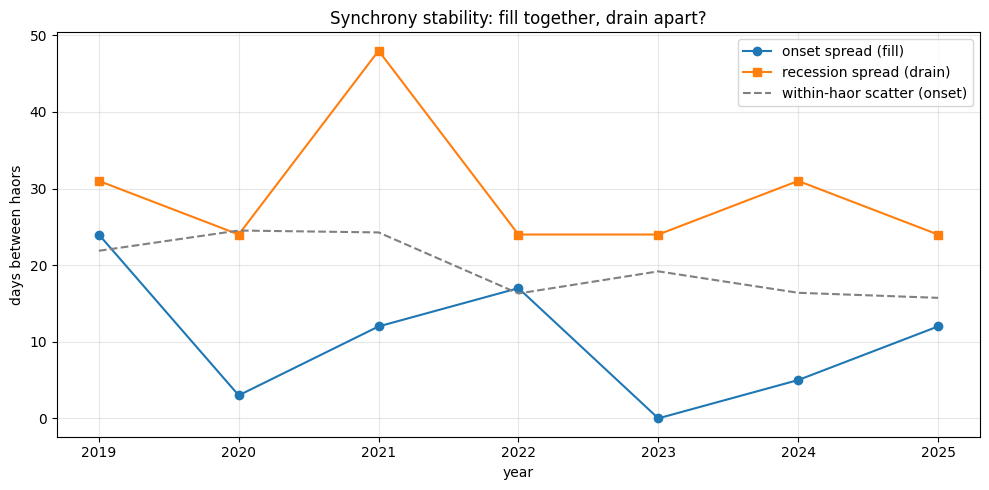

In [6]:
# %%
# ================= CROSS-YEAR FIG 1: synchrony stability =================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(summary_df["year"], summary_df["onset_spread"], "o-", label="onset spread (fill)")
ax.plot(summary_df["year"], summary_df["recession_spread"], "s-", label="recession spread (drain)")
ax.plot(summary_df["year"], summary_df["onset_within_std"], "--", color="grey", label="within-haor scatter (onset)")
ax.set_xlabel("year"); ax.set_ylabel("days between haors")
ax.set_title("Synchrony stability: fill together, drain apart?")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "multiyear_synchrony.png"), dpi=150); plt.show()


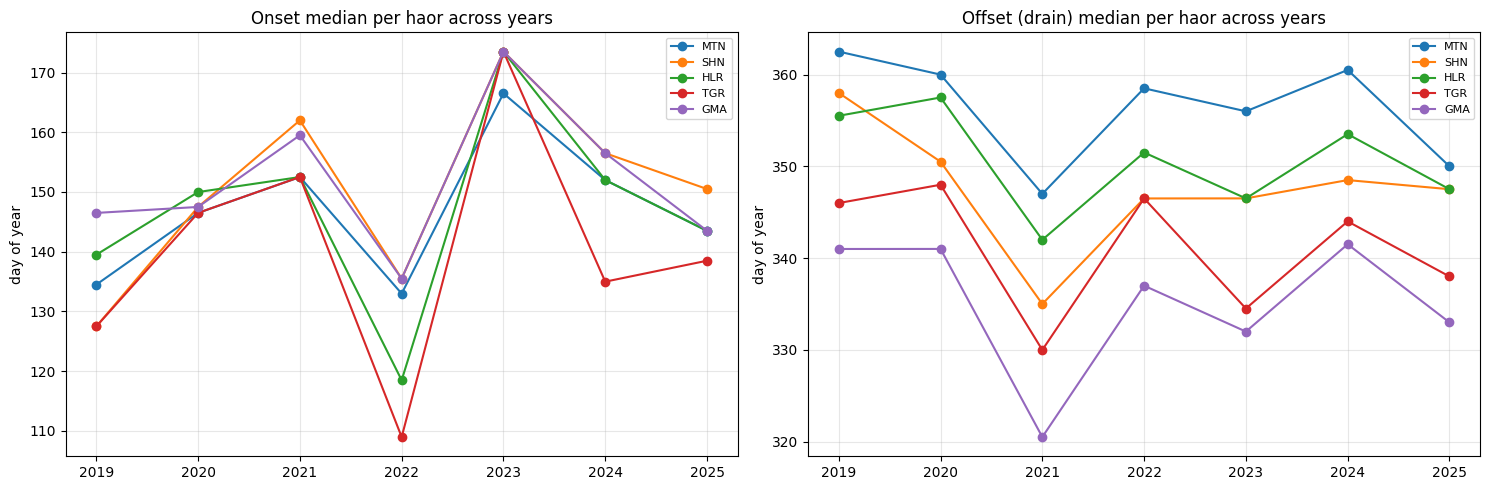

Drain order each year (earliest -> latest):
  2019: GMA < TGR < HLR < SHN < MTN
  2020: GMA < TGR < SHN < HLR < MTN
  2021: GMA < TGR < SHN < HLR < MTN
  2022: GMA < SHN < TGR < HLR < MTN
  2023: GMA < TGR < HLR < SHN < MTN
  2024: GMA < TGR < SHN < HLR < MTN
  2025: GMA < TGR < HLR < SHN < MTN


In [7]:
# %%
# ================= CROSS-YEAR FIG 2: per-haor timing + drain order =================
onset_M = pd.DataFrame({y: results[y]["onset_df"].set_index("haor_id")["onset_median"] for y in results})
offset_M = pd.DataFrame({y: results[y]["offset_df"].set_index("haor_id")["offset_median"] for y in results})

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for hid in onset_M.index: ax[0].plot(onset_M.columns, onset_M.loc[hid], "o-", label=hid)
ax[0].set_title("Onset median per haor across years"); ax[0].set_ylabel("day of year"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
for hid in offset_M.index: ax[1].plot(offset_M.columns, offset_M.loc[hid], "o-", label=hid)
ax[1].set_title("Offset (drain) median per haor across years"); ax[1].set_ylabel("day of year"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "multiyear_perhaor_timing.png"), dpi=150); plt.show()

print("Drain order each year (earliest -> latest):")
drain_orders = {}
for y in results:
    od = results[y]["offset_df"].sort_values("offset_median")["haor_id"].tolist()
    drain_orders[y] = od
    print(f"  {y}: {' < '.join(od)}")


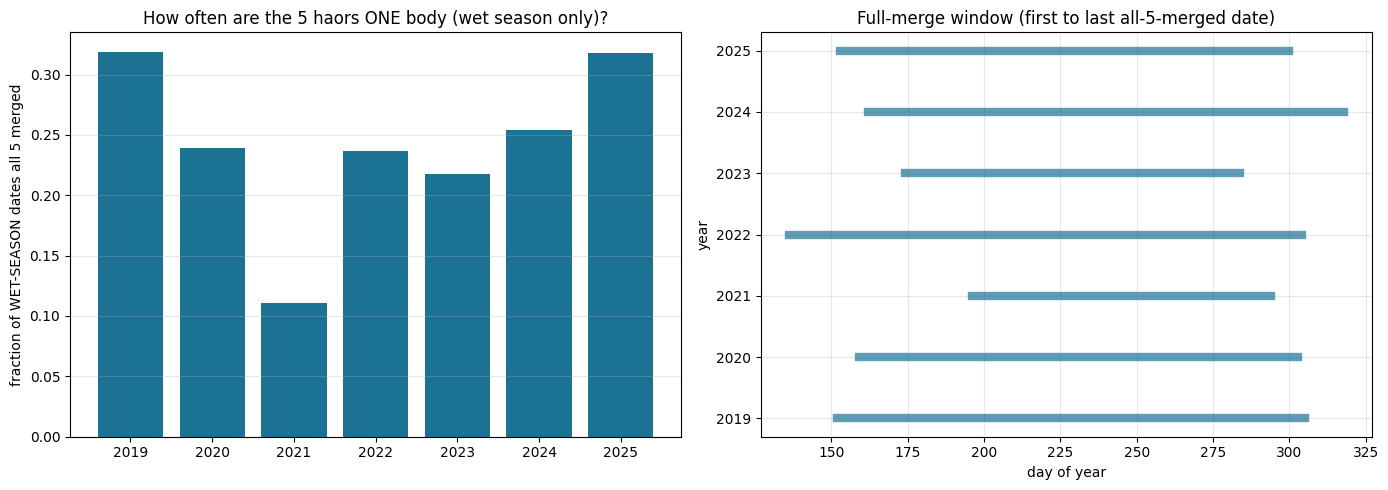

In [8]:
# %%
# ================= CROSS-YEAR FIG 3 (v2): WET-SEASON merge metrics =================
# v1 divided merged dates by ALL observed dates including the dry season, which
# diluted the fraction. v2 divides by wet-season dates only, and also shows the
# merge WINDOW (first to last full-merge day) per year.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(summary_df["year"].astype(str), summary_df["ws_merge_frac"], color="#1C7293")
ax[0].set_ylabel("fraction of WET-SEASON dates all 5 merged")
ax[0].set_title("How often are the 5 haors ONE body (wet season only)?")
ax[0].grid(alpha=.3, axis="y")
for _, r in summary_df.iterrows():
    ax[1].plot([r["merge_first"], r["merge_last"]], [r["year"]] * 2, "-", lw=6, color="#1C7293", alpha=.7)
ax[1].set_xlabel("day of year"); ax[1].set_ylabel("year")
ax[1].set_title("Full-merge window (first to last all-5-merged date)")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "multiyear_merge_v2.png"), dpi=150); plt.show()


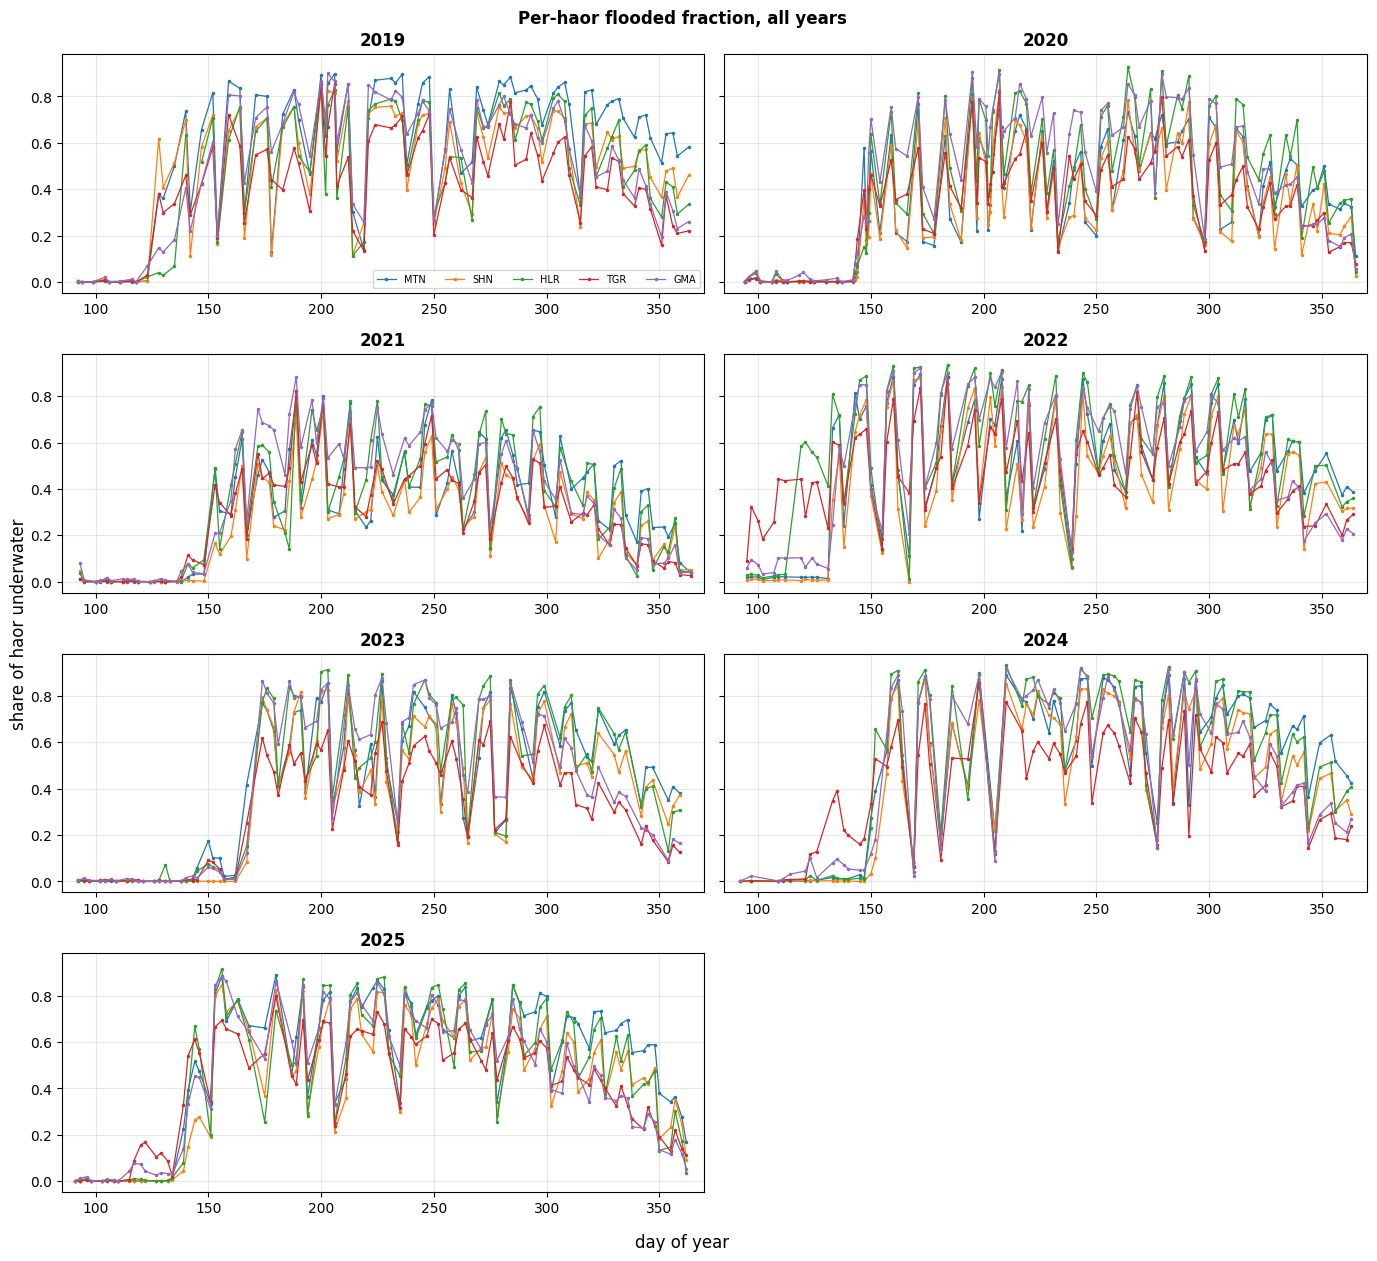

In [9]:
# %%
# ================= NEW GRID 1: hydrographs, one panel per year =================
ny = len(results); ncol = 2; nrow = int(np.ceil(ny / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 3.2 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()
for k, y in enumerate(sorted(results)):
    r = results[y]; d = r["days"]; o = np.argsort(d)
    for hid, fr in r["curves"].items():
        axes[k].plot(d[o], fr[o], marker="o", ms=1.5, lw=.9, label=hid)
    axes[k].set_title(str(y), fontweight="bold"); axes[k].grid(alpha=.3)
    axes[k].set_xlim(85, 370)
    if k == 0: axes[k].legend(fontsize=7, ncol=5)
for k in range(len(results), len(axes)): axes[k].axis("off")
fig.suptitle("Per-haor flooded fraction, all years", fontweight="bold")
fig.supxlabel("day of year"); fig.supylabel("share of haor underwater")
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "grid_hydrographs.png"), dpi=150); plt.show()


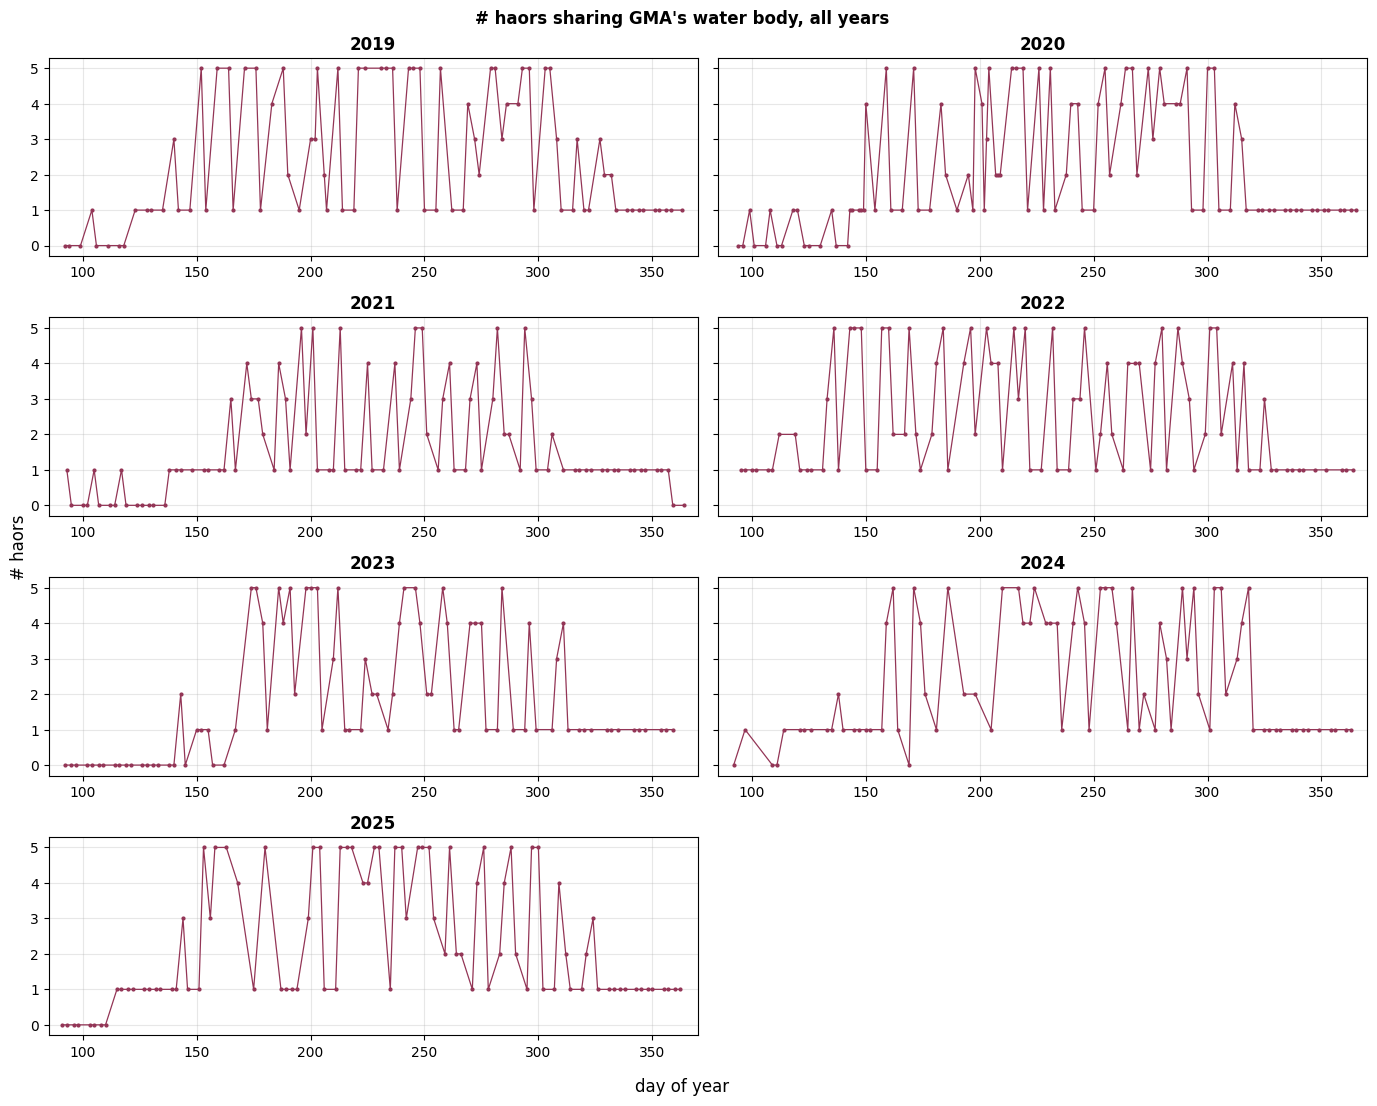

In [10]:
# %%
# ================= NEW GRID 2: connectivity (# haors sharing GMA), per year =================
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.8 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()
for k, y in enumerate(sorted(results)):
    r = results[y]
    central = CENTRAL_HAOR if CENTRAL_HAOR in HAOR_IDS else HAOR_IDS[0]
    mv = r["matrix_df"][r["matrix_df"][central] >= 0]
    linked = [int(sum(row[h] == row[central] and row[central] > 0 for h in HAOR_IDS))
              for _, row in mv.iterrows()]
    axes[k].plot(mv["doy"], linked, "o-", ms=2, lw=.9, color="#933556")
    axes[k].set_title(str(y), fontweight="bold"); axes[k].set_ylim(-0.3, 5.3); axes[k].grid(alpha=.3)
    axes[k].set_xlim(85, 370)
for k in range(len(results), len(axes)): axes[k].axis("off")
fig.suptitle(f"# haors sharing {CENTRAL_HAOR}'s water body, all years", fontweight="bold")
fig.supxlabel("day of year"); fig.supylabel("# haors")
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "grid_connectivity.png"), dpi=150); plt.show()


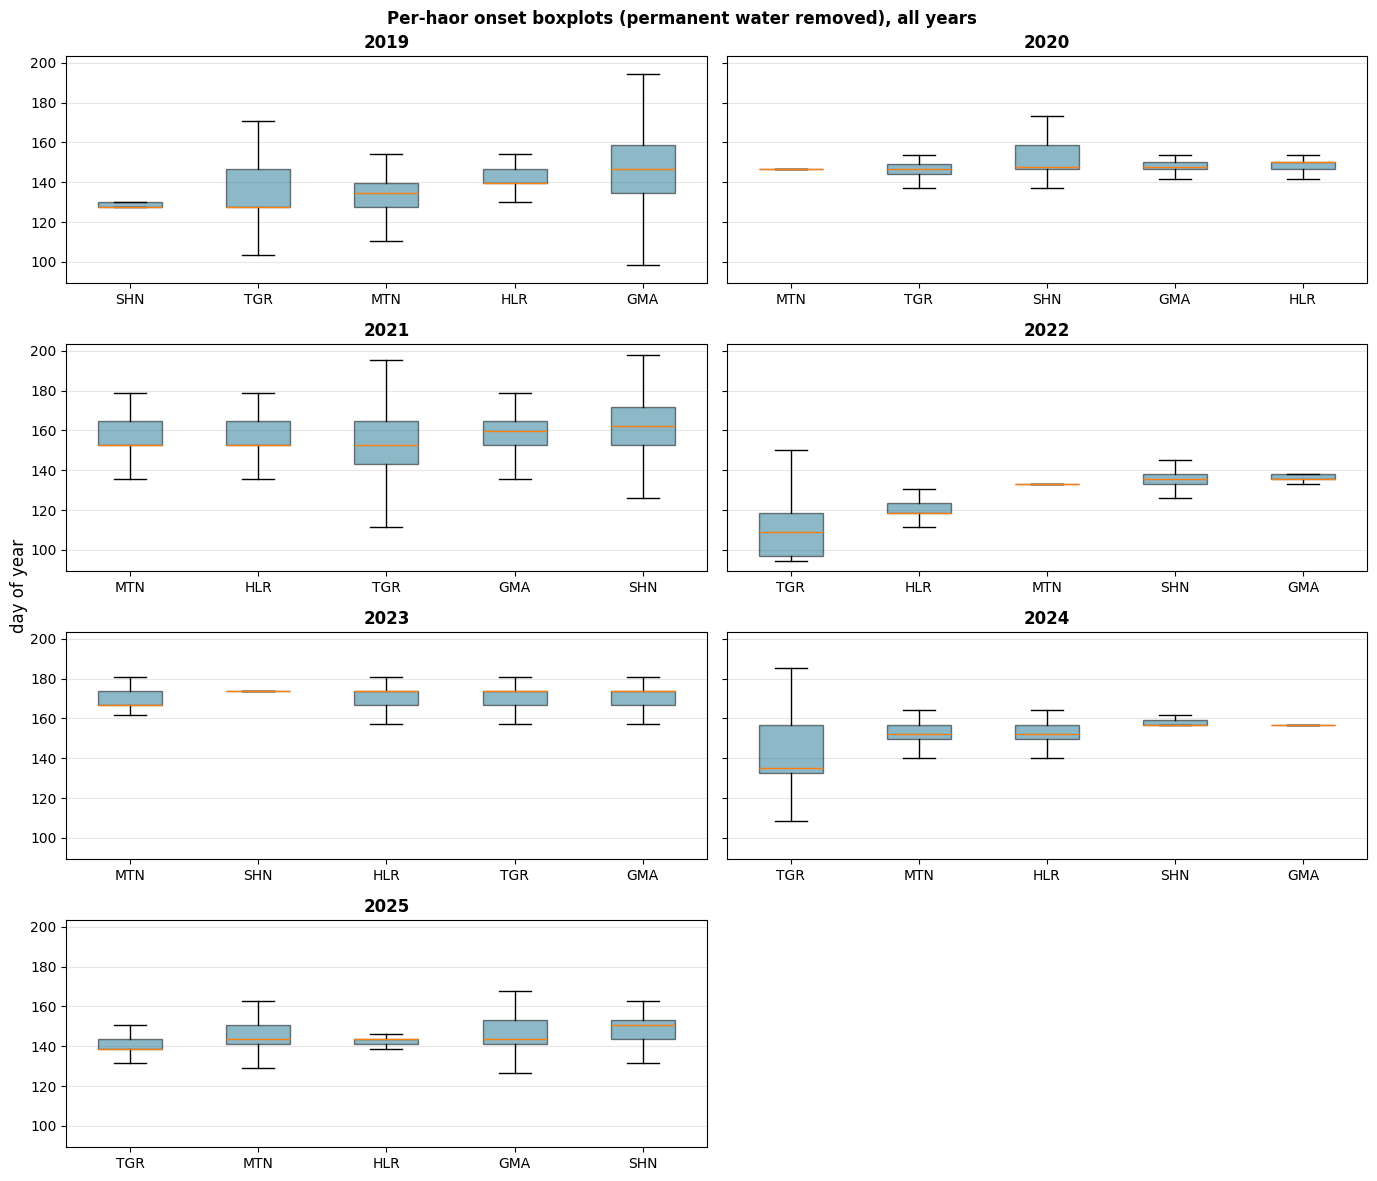

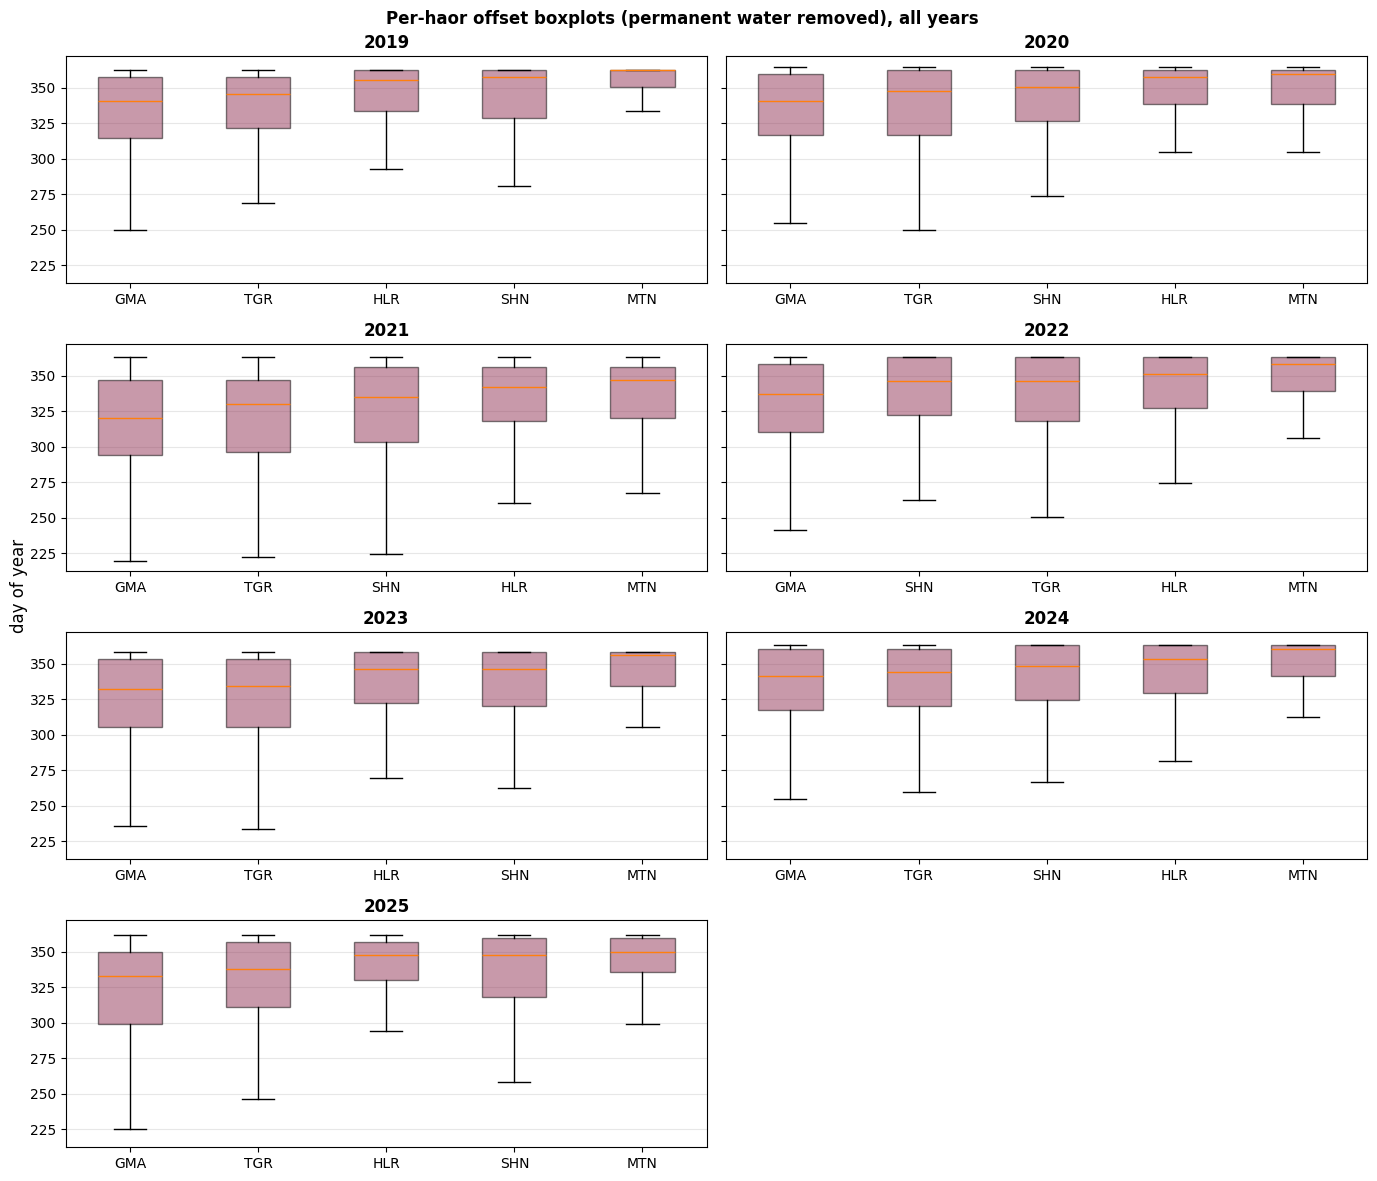

In [11]:
# %%
# ================= NEW GRIDS 3+4: onset and offset boxplots per year =================
for tag, dist_key, color in [("onset", "onset_dist", "#1C7293"), ("offset", "offset_dist", "#933556")]:
    fig, axes = plt.subplots(nrow, ncol, figsize=(14, 3.0 * nrow), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for k, y in enumerate(sorted(results)):
        r = results[y]
        med = r[f"{tag}_df"].sort_values(f"{tag}_median")
        order = med["haor_id"].tolist()
        bp = axes[k].boxplot([r[dist_key][h] for h in order], tick_labels=order,
                             showfliers=False, patch_artist=True)
        for p in bp["boxes"]: p.set_facecolor(color); p.set_alpha(.5)
        axes[k].set_title(str(y), fontweight="bold"); axes[k].grid(alpha=.3, axis="y")
    for k in range(len(results), len(axes)): axes[k].axis("off")
    fig.suptitle(f"Per-haor {tag} boxplots (permanent water removed), all years", fontweight="bold")
    fig.supylabel("day of year")
    plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, f"grid_{tag}_box.png"), dpi=150); plt.show()


In [12]:
# %%
# ================= KENDALL'S W: is the drain order non-random? =================
# Ranks the 5 haors by offset median in each year and tests agreement of the
# rankings across years. W=1 means identical order every year; the chi-square
# approximation gives a p-value. This formalizes "GMA first, MTN last, 7/7".
rank_M = offset_M.rank(axis=0)          # rank within each year (1 = earliest drain)
m = rank_M.shape[1]                      # number of years (judges)
n = rank_M.shape[0]                      # number of haors (items)
R = rank_M.sum(axis=1)                   # total rank per haor
S = float(((R - R.mean()) ** 2).sum())
W = 12 * S / (m ** 2 * (n ** 3 - n))
chi2 = m * (n - 1) * W
from scipy.stats import chi2 as chi2_dist
p = float(chi2_dist.sf(chi2, df=n - 1))
print("mean drain rank per haor (1 = drains first):")
print((R / m).sort_values().to_string())
print(f"\nKendall's W = {W:.3f}  (1 = perfectly consistent order)")
print(f"chi2 = {chi2:.1f}, df = {n-1}, p = {p:.2e}")
print("-> small p: the drain order is NOT random across years; it is structural.")


mean drain rank per haor (1 = drains first):
haor_id
GMA    1.000000
TGR    2.142857
SHN    3.142857
HLR    3.714286
MTN    5.000000

Kendall's W = 0.927  (1 = perfectly consistent order)
chi2 = 25.9, df = 4, p = 3.25e-05
-> small p: the drain order is NOT random across years; it is structural.


In [13]:
# %%
# ================= MECHANISM v2: OUTWARD rim elevation vs drain order =================
# Why v1 failed: the rim corridor buffered BOTH ways, so it swallowed haor-floor
# and open-water pixels, and p5 of 20k pixels found the floor (0 m) for every
# haor -> the metric saturated and rho was exactly 0. Fixes:
#   1. outward-only ring: buffer(150).difference(polygon) — floor excluded
#   2. permanent water masked with JRC occurrence (>75%)
#   3. exact-zero / nodata pixels dropped (FABDEM water artifacts pin at 0)
UTM = "EPSG:32646"
with rasterio.open(FABDEM_TIF) as fsrc, rasterio.open(JRC_TIF) as jsrc:
    h_utm = haors.to_crs(UTM)
    rim_rows = []
    for _, h in h_utm.iterrows():
        ring = h.geometry.buffer(150).difference(h.geometry)     # OUTWARD ring only
        ring_r = gpd.GeoSeries([ring], crs=UTM).to_crs(fsrc.crs).iloc[0]
        try:
            dat, tr = rmask(fsrc, [mapping(ring_r)], crop=True, filled=False)
        except ValueError:
            print(f"  {h.haor_id}: ring outside FABDEM"); continue
        elev = np.ma.filled(dat[0], np.nan).astype("float32")
        # JRC occurrence onto the same grid -> mask permanent water
        jrc_g = np.full(elev.shape, np.nan, "float32")
        reproject(rasterio.band(jsrc, 1), jrc_g, src_transform=jsrc.transform,
                  src_crs=jsrc.crs, dst_transform=tr, dst_crs=fsrc.crs,
                  resampling=Resampling.bilinear)
        keep = np.isfinite(elev) & (np.abs(elev) > 0.05) & ~(np.isfinite(jrc_g) & (jrc_g > 75))
        vals = elev[keep]
        if vals.size < 100:
            print(f"  {h.haor_id}: too few clean rim pixels ({vals.size})"); continue
        rim_rows.append(dict(haor_id=h.haor_id, n_px=int(vals.size),
            rim_p2=float(np.percentile(vals, 2)), rim_p5=float(np.percentile(vals, 5)),
            rim_p10=float(np.percentile(vals, 10)), rim_median=float(np.median(vals))))
rim_df = pd.DataFrame(rim_rows).set_index("haor_id")
rim_df = rim_df.join((offset_M.rank(axis=0).mean(axis=1)).rename("mean_drain_rank"))
rim_df.to_csv(os.path.join(ANALYSIS_ROOT, "rim_elevation_vs_drain_v2.csv"))
print(rim_df.sort_values("mean_drain_rank").to_string())
rho, pval = spearmanr(rim_df["mean_drain_rank"], rim_df["rim_p5"])
print(f"\nSpearman (drain rank vs OUTWARD rim p5): rho={rho:.2f}, p={pval:.3f}")
print("Caveat: FABDEM vertical error (~1 m+) vs total relief (~0-6 m) is large in")
print("this basin; if values still cluster, the DEM cannot resolve the mechanism")
print("and the SWOT levels become the better mechanism probe.")

         n_px  rim_p2  rim_p5  rim_p10  rim_median  mean_drain_rank
haor_id                                                            
GMA      8601     0.5     1.0     2.00       4.230         1.000000
TGR      7566     1.5     2.5     2.84       4.965         2.142857
SHN      7878     0.5     0.5     1.00       4.500         3.142857
HLR      6122     0.5     0.5     1.00       4.650         3.714286
MTN      6491     1.5     2.5     2.74       4.390         5.000000

Spearman (drain rank vs OUTWARD rim p5): rho=0.00, p=1.000
Caveat: FABDEM vertical error (~1 m+) vs total relief (~0-6 m) is large in
this basin; if values still cluster, the DEM cannot resolve the mechanism
and the SWOT levels become the better mechanism probe.


In [14]:
# %%
# ================= MECHANISM 2: inter-haor SILL elevations =================
# For each ADJACENT pair, the boundary corridor's low elevation is the sill the
# water must top for the pair to merge. Lower sill = pair should merge earlier
# and stay merged longer. Output: pairwise sill matrix to compare against the
# connection matrix later.
pairs = []
with rasterio.open(FABDEM_TIF) as fsrc:
    for i in range(len(h_utm)):
        for j in range(i + 1, len(h_utm)):
            a, b = h_utm.iloc[i], h_utm.iloc[j]
            corridor = a.geometry.buffer(300).intersection(b.geometry.buffer(300))
            if corridor.is_empty: continue
            cor_r = gpd.GeoSeries([corridor], crs=UTM).to_crs(fsrc.crs).iloc[0]
            try:
                dat, _ = rmask(fsrc, [mapping(cor_r)], crop=True, filled=False)
            except ValueError:
                continue
            vals = np.ma.filled(dat[0], np.nan).astype("float32")
            vals = vals[np.isfinite(vals)]
            if vals.size < 10: continue
            pairs.append(dict(pair=f"{a.haor_id}-{b.haor_id}",
                sill_p5=float(np.percentile(vals, 5)),
                sill_median=float(np.median(vals)), n_px=vals.size))
sill_df = pd.DataFrame(pairs).sort_values("sill_p5")
sill_df.to_csv(os.path.join(ANALYSIS_ROOT, "interhaor_sills.csv"), index=False)
print("Inter-haor boundary sill elevations (lower = merges first):")
print(sill_df.to_string(index=False))
print("\nRead: pairs with the LOWEST sills should be the FIRST to appear merged in")
print("the connection matrix each rising season, and the LAST to separate.")


Inter-haor boundary sill elevations (lower = merges first):
   pair  sill_p5  sill_median  n_px
MTN-TGR      0.0         2.92  7449
MTN-GMA      0.0         4.04  1520
HLR-GMA      0.0         3.16  7232
SHN-HLR      0.5         3.83  6272
TGR-GMA      0.5         5.00  7619
SHN-GMA      0.5         4.05  4140
MTN-SHN      3.0         5.17  6958

Read: pairs with the LOWEST sills should be the FIRST to appear merged in
the connection matrix each rising season, and the LAST to separate.


In [15]:
# %%
# ================= SWOT (v3): load precomputed per-haor WSE =================
# The heavy extraction now lives in swot_extract_wse.py (run it once on the
# server; it is resumable). This cell just loads its output — seconds, not hours.
SWOT_CSV = os.path.join(ANALYSIS_ROOT, "swot_perhaor_wse.csv")
assert os.path.exists(SWOT_CSV), "run swot_extract_wse.py first"
swot_df = pd.read_csv(SWOT_CSV, parse_dates=["dt"])
# safety dedup even if the script's final pass was interrupted:
swot_df["res_rank"] = (swot_df["res"] != "100m").astype(int)
swot_df = (swot_df.sort_values(["dt", "haor_id", "res_rank", "n"],
                               ascending=[True, True, True, False])
                  .drop_duplicates(subset=["dt", "haor_id"], keep="first"))
print(f"{len(swot_df)} per-haor WSE rows | dates per year:",
      swot_df.groupby("year")["doy"].nunique().to_dict())

960 per-haor WSE rows | dates per year: {2023: 25, 2024: 64, 2025: 67, 2026: 3}


          count   mean    std    min    25%    50%    75%    max
state                                                           
merged    239.0  0.175  0.331  0.002  0.064  0.107  0.159  2.374
separate  636.0  0.294  0.396  0.000  0.085  0.151  0.280  2.468


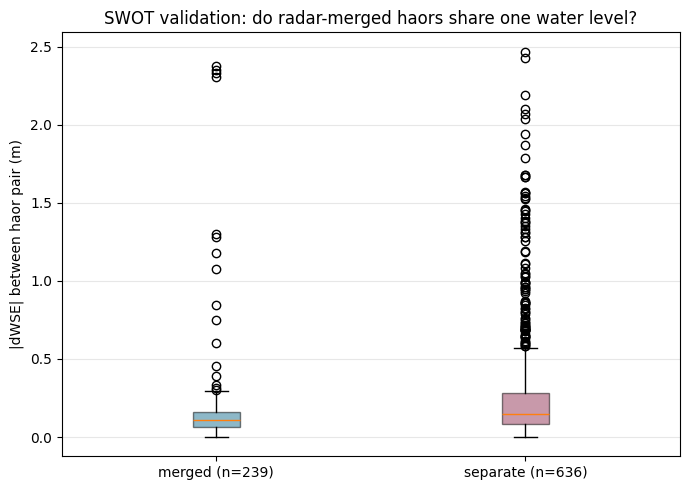

In [16]:
# %%
# ================= SWOT (v3): validation — merged pairs share one level? =================
# BUG FIXED vs v2: swot rows were duplicated per (date, haor) because 100m and
# 250m products cover the same pass, so g.loc[haor] returned a SERIES and every
# dwse became a table instead of a number — that is what crashed the figure.
# Rows are now unique per (dt, haor); we also aggregate to one value per
# (year, doy, haor) in case two scenes of the same day both saw a haor.
TOL_DAYS = 3
daily = (swot_df.groupby(["year", "doy", "haor_id"])["wse_median"]
                .median().reset_index())
pair_rows = []
for (yr, doy), grp in daily.groupby(["year", "doy"]):
    if yr not in results: continue
    mat = results[yr]["matrix_df"]
    mat = mat[mat[HAOR_IDS[0]] >= 0]
    if not len(mat): continue
    k = (mat["doy"] - doy).abs().idxmin()
    if abs(mat.loc[k, "doy"] - doy) > TOL_DAYS: continue
    comp = mat.loc[k, HAOR_IDS]
    g = grp.set_index("haor_id")["wse_median"]          # unique index now
    hids = [h for h in HAOR_IDS if h in g.index]
    for i in range(len(hids)):
        for j in range(i + 1, len(hids)):
            a, b = hids[i], hids[j]
            if comp[a] <= 0 or comp[b] <= 0: continue
            pair_rows.append(dict(year=yr, doy=doy, pair=f"{a}-{b}",
                dwse=float(abs(g[a] - g[b])),
                state="merged" if comp[a] == comp[b] else "separate"))
pairs_df = pd.DataFrame(pair_rows)
if len(pairs_df):
    pairs_df.to_csv(os.path.join(ANALYSIS_ROOT, "swot_pair_validation.csv"), index=False)
    print(pairs_df.groupby("state")["dwse"].describe().round(3).to_string())
    fig, ax = plt.subplots(figsize=(7, 5))
    data = [pairs_df.loc[pairs_df.state == s, "dwse"].values for s in ["merged", "separate"]]
    bp = ax.boxplot(data, tick_labels=[f"merged (n={len(data[0])})",
                                       f"separate (n={len(data[1])})"],
                    showfliers=True, patch_artist=True)
    for p, c in zip(bp["boxes"], ["#1C7293", "#933556"]): p.set_facecolor(c); p.set_alpha(.5)
    ax.set_ylabel("|dWSE| between haor pair (m)")
    ax.set_title("SWOT validation: do radar-merged haors share one water level?")
    ax.grid(alpha=.3, axis="y")
    plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "swot_validation.png"), dpi=150); plt.show()
else:
    print("no SWOT date matched a connectivity date within +/-3 days; widen TOL_DAYS to 5.")